## Imports

In [409]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using Plots
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`


In [663]:
# Problem parameters
T = 100
Δt = 0.2
U_goal = GATES.X
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)
seed = 18
F=0.9999
num_iter = 500
hess = false
hess_iter = 100

a_bound = 1.0
dda_bound = 5.0

5.0

In [664]:
# Default
Random.seed!(seed)
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; Δt_min=Δt, Δt_max=Δt, a_bound=a_bound, dda_bound=dda_bound, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
if hess
    solve!(def, max_iter=hess_iter, print_level=1)
end

    constructing UnitarySmoothPulseProblem...
	using integrator: DataType
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    11192
Number of nonzeros in inequality constraint Jacobian.:        8
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     1686
                     variables with only lower bounds:        0
                variables with lower and upper b

In [665]:
# Adjoint, rollout initialization
Random.seed!(1)
∂ₑHₐ = [PAULIS.Z]
varsys_add = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)

var_count = length(varsys_add.G_vars)

var_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for _ in 1:var_count],
    a_bound=a_bound, 
    dda_bound=dda_bound,
    Δt_max=Δt,
    Δt_min=Δt,
    Q=0.0,
    Q_r = 1.0,   # > 0
    Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
    piccolo_options = PiccoloOptions(verbose=false)
)

# init_traj = deepcopy(var_prob.trajectory)
# init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys_add)

# var_prob = UnitaryVariationalProblem(
#     varsys_add, U_goal, T, Δt;
#     robust_times = [[T] for _ in 1:var_count],
#     init_trajectory = remove_components(init_traj, [:Ũ⃗ᵥ1, :Ũ⃗ᵥ2, :Ũ⃗ᵥ3]),
#     a_bound=a_bound, 
#     dda_bound=dda_bound,
#     Δt_max=Δt,
#     Δt_min=Δt,
#     Q=0.0,
#     Q_r = 1.0,   # > 0
#     Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
#     piccolo_options = PiccoloOptions(verbose=false)
# )
push!(var_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory))
solve!(var_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
if hess
    solve!(var_prob, max_iter=hess_iter, print_level=5)
end

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    33152
Number of nonzeros in inequality constraint Jacobian.:        8
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2478
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      594
                     variables with only upper bounds:        0
Total number of equality co

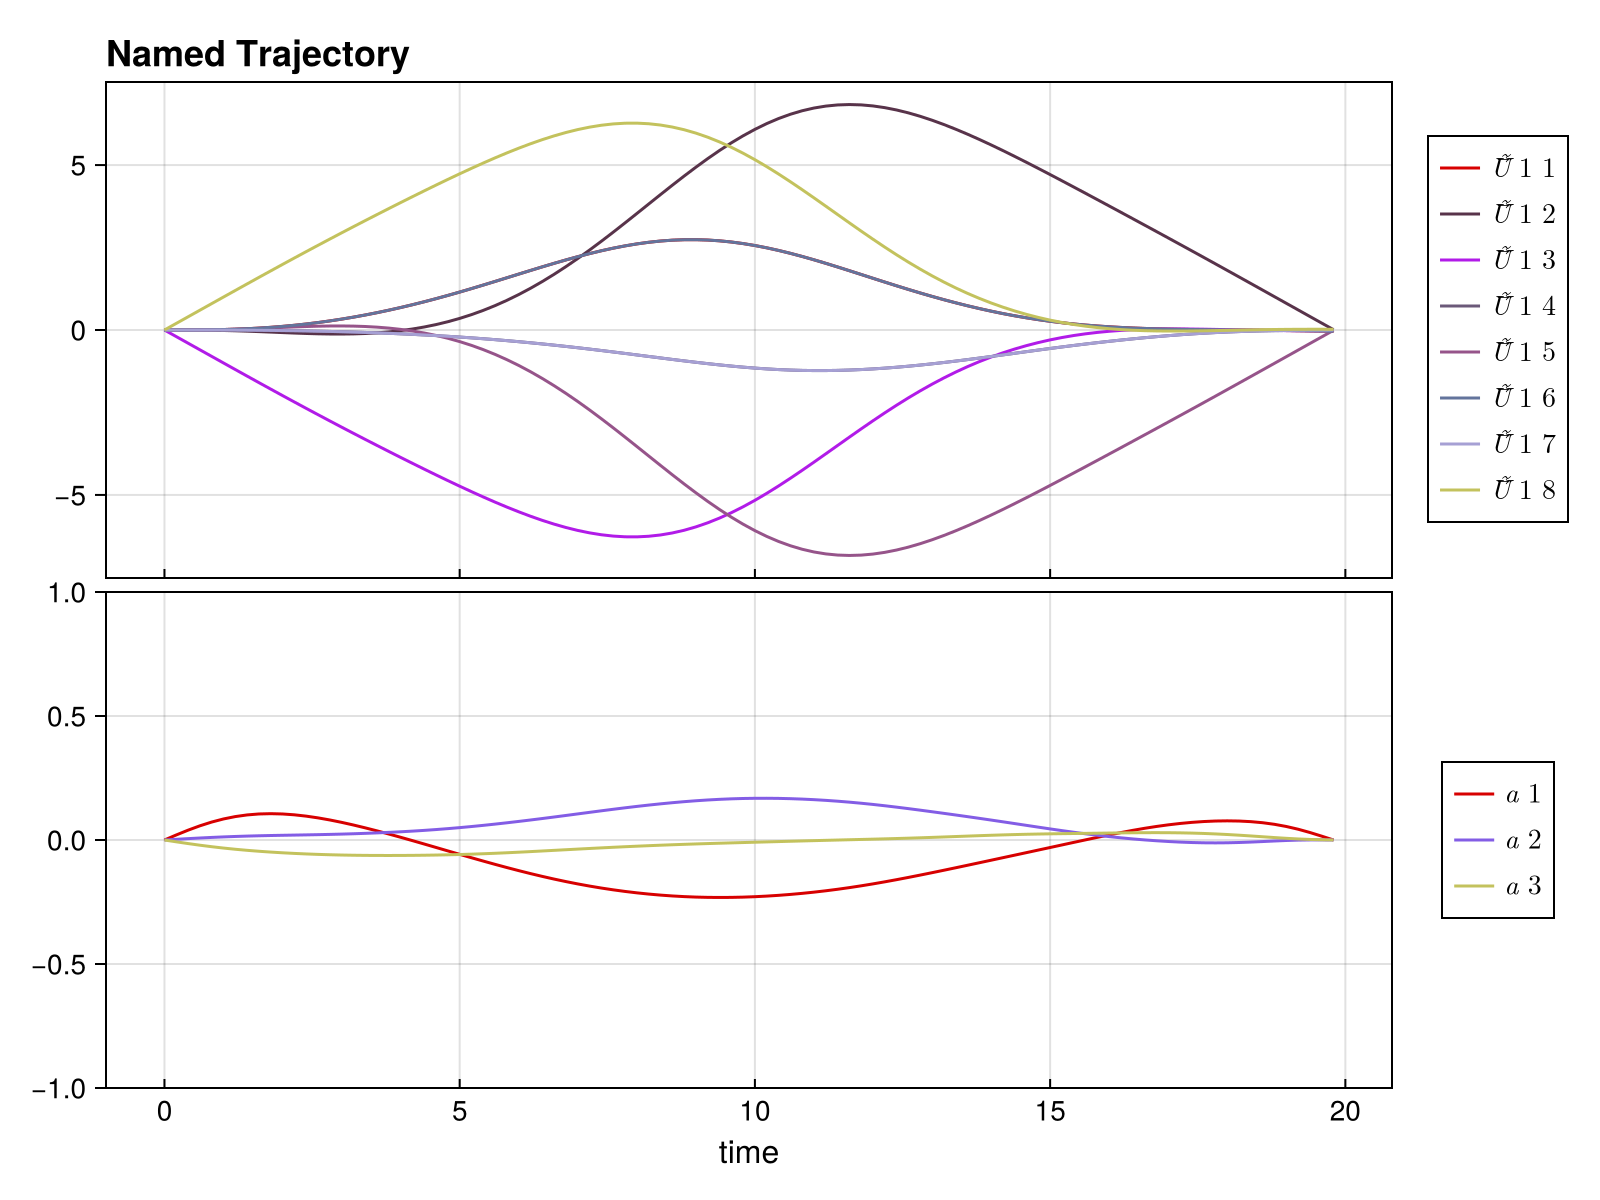

In [666]:
var_traj = var_prob.trajectory
CairoMakie.plot(var_traj, [:Ũ⃗ᵥ1, :a])

In [667]:
var_prob.trajectory.Δt[1]

0.2

In [668]:
∂ₑH = [PAULIS.Z]
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
error_ops = [PAULIS.Z]
function var_obj(prob::DirectTrajOptProblem, H_drive::Vector{Matrix{ComplexF64}}, error_ops::Vector{Matrix{ComplexF64}})
    Δt = prob.trajectory.Δt[1]
    varsys = VariationalQuantumSystem(
        H_drive,
        error_ops
    )
    ww = iso_vec_to_operator(variational_unitary_rollout(prob.trajectory, varsys)[2][1][:,end])
    d = size(ww)[1]
    return norm(tr(ww'ww)) / (T * Δt)^2 / d
end
var_obj_var = var_obj(var_prob, H_drive, error_ops)

5.802163195020355e-6

In [669]:
using NamedTrajectories

function SpaceNormOriginal(traj::NamedTrajectory, U_goal::AbstractMatrix{<:Number}, Hₑ::AbstractMatrix{<:Number})
    T = traj.T
    first_order_terms = Vector{Matrix{ComplexF64}}(undef, T)
    first_order_integral = zeros(ComplexF64, size(U_goal))

    for i in 1:T
        U = iso_vec_to_operator(traj.Ũ⃗[:, i])
        first_order_integral += U' * Hₑ * U
        first_order_terms[i] = first_order_integral
    end
    d = size(U_goal)[1]
    metric = norm(tr(first_order_terms[T]'first_order_terms[T])) / (d * T^2)
    return metric
end

tog_var = SpaceNormOriginal(var_prob.trajectory, U_goal, GATES.Z)
tog_var

9.565331341988488e-6

In [670]:
tog_var / var_obj_var

1.6485801968131184

In [750]:
using NamedTrajectories

function commutator(A::AbstractMatrix{<:Number}, B::AbstractMatrix{<:Number})
    return A*B - B*A
end

function SpaceNormPert(prob::DirectTrajOptProblem, H_drive::Vector{Matrix{ComplexF64}}, U_goal::AbstractMatrix{<:Number}, Eₖ::AbstractMatrix{<:Number}, j::Int=1)
    traj = prob.trajectory
    T = traj.T
    first_order_terms = Vector{Matrix{ComplexF64}}(undef, T)
    first_order_integral = zeros(ComplexF64, size(U_goal))
    order_vec = []
    controls = traj.a
    Δt = traj.Δt[1]
    varsys = VariationalQuantumSystem(
        H_drive,
        [Eₖ]
    )
    for i in 1:T
        Hₖ = sum(controls[l,i] * drive for (l, drive) in enumerate(H_drive))
        approx = Eₖ * Δt
        ad_n = Eₖ
        for n in 1:(j-1)
            # get the different orders of the Hadamard lemma
            ad_n = copy(commutator(Hₖ, ad_n))
            nth_order = copy(((1.0im)^n * Δt^(n + 1)) / factorial(big(n + 1)) * ad_n)
            approx += nth_order
        end
        #U = iso_vec_to_operator(traj.Ũ⃗[:, i])
        U = iso_vec_to_operator(variational_unitary_rollout(prob.trajectory, varsys)[1][:,i])
        first_order_integral += U' * approx * U 
        first_order_terms[i] = first_order_integral
    end
    d = size(U_goal)[1]
    metric = norm(tr(first_order_terms[T]'first_order_terms[T])) / (d * Δt^2 * T^2)
    return metric
end

SpaceNormPert (generic function with 2 methods)

In [752]:
error_ops = [GATES.Z]
t_vec_p = []
v_vec = []

j_vals = 1:50

for j in j_vals
    push!(t_vec_p, SpaceNormPert(var_prob, H_drive, U_goal, GATES.Z, j))
    push!(v_vec, var_obj(var_prob, H_drive, error_ops))
end

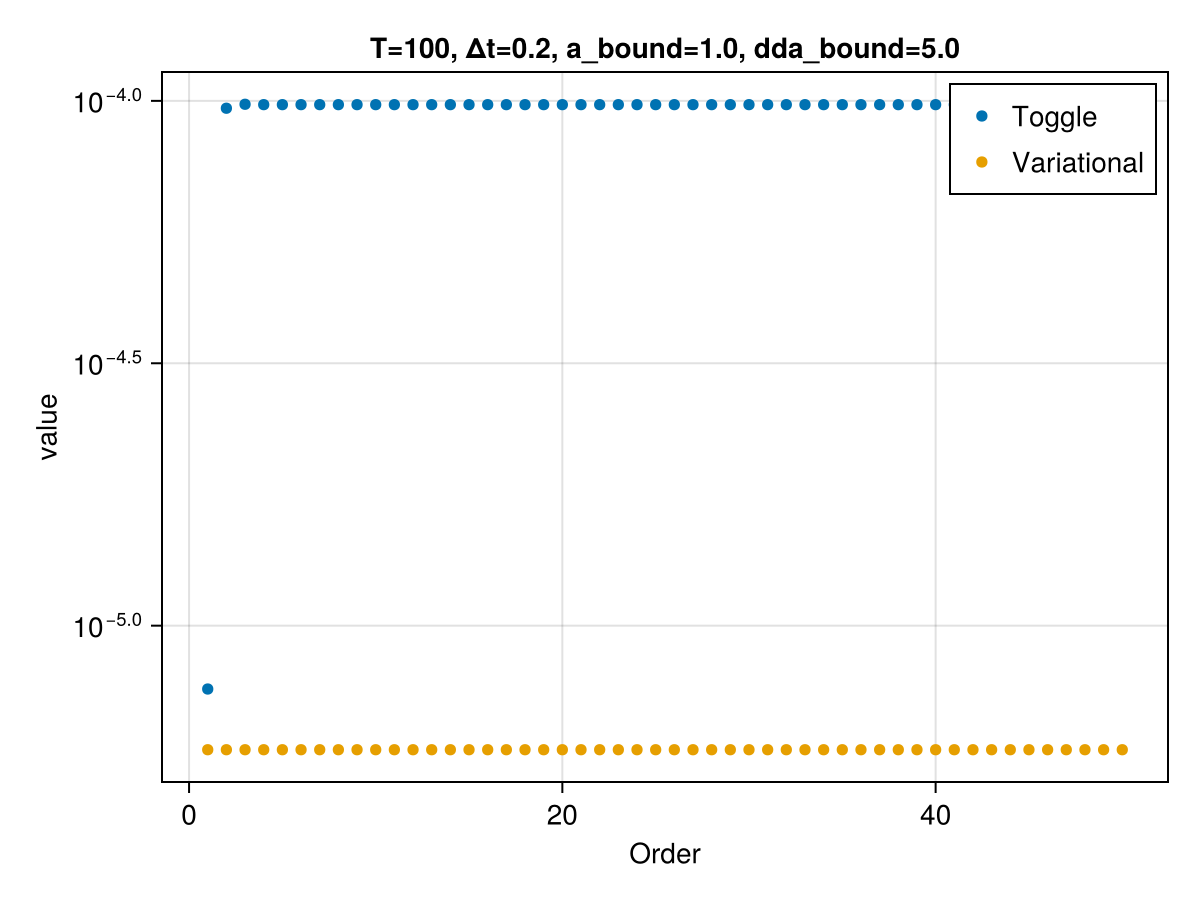

In [753]:
using CairoMakie

T = var_prob.trajectory.T
Δt = var_prob.trajectory.Δt[1]

fig = Figure()
ax = Axis(fig[1, 1], title="T=$T, Δt=$Δt, a_bound=$a_bound, dda_bound=$dda_bound",xlabel="Order", ylabel="value", yscale=log10)

CairoMakie.scatter!(ax, j_vals, t_vec_p; label="Toggle", markersize=8)
CairoMakie.scatter!(ax, j_vals, v_vec; label="Variational", markersize=8)

axislegend(ax)

fig

# Upsampling

In [754]:
using DataInterpolations

In [755]:
function upsample_constant_controls(vals::AbstractArray; factor::Int=2)
    vals_up = repeat(vals, inner=factor)
    return vals_up
end

# Example
vals = [1, 2, 3]
dts  = [0.2, 0.2, 0.2]

vals_up = upsample_constant_controls(vals; factor=3)

println(vals_up)  # [1, 1, 2, 2, 3, 3]
#println(dts_up) 

[1, 1, 1, 2, 2, 2, 3, 3, 3]


In [756]:
function upsample_matrix(controls::AbstractArray, dts::AbstractArray; factor::Int=2)
    new_controls = []
    for c in eachrow(controls)
        new_c = upsample_constant_controls(c; factor=factor)
        T = length(c)
        push!(new_controls, new_c)
    end
    dts_up = dts[1] / factor .* ones(length(dts) * factor * T)
    return new_controls, dts_up
end

upsample_matrix (generic function with 1 method)

In [757]:
factor = 3
controls = var_traj.a
dts = var_traj.Δt
new_controls, dts_up = upsample_matrix(controls, dts; factor=factor)


(Any[[0.0, 0.0, 0.0, 0.02031022596102128, 0.02031022596102128, 0.02031022596102128, 0.03963093966364116, 0.03963093966364116, 0.03963093966364116, 0.05717470504581705  …  0.04343671836078615, 0.030231954059974277, 0.030231954059974277, 0.030231954059974277, 0.015437415786976357, 0.015437415786976357, 0.015437415786976357, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0027990584413722743, 0.0027990584413722743, 0.0027990584413722743, 0.005505414619989015, 0.005505414619989015, 0.005505414619989015, 0.008048411103775754  …  -0.00048788079332832274, 0.00028916932475211987, 0.00028916932475211987, 0.00028916932475211987, 0.00036215979571289653, 0.00036215979571289653, 0.00036215979571289653, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, -0.007318170195160688, -0.007318170195160688, -0.007318170195160688, -0.014369976339934028, -0.014369976339934028, -0.014369976339934028, -0.020978395087354218  …  0.004236208490848103, 0.0022678594199889122, 0.0022678594199889122, 0.0022678594199889122, 0.000910597386339633, 0.0009

In [758]:
M = reduce(vcat, [v' for v in new_controls])

3×300 Matrix{Float64}:
 0.0  0.0  0.0   0.0203102    0.0203102   …  0.0154374    0.0  0.0  0.0
 0.0  0.0  0.0   0.00279906   0.00279906     0.00036216   0.0  0.0  0.0
 0.0  0.0  0.0  -0.00731817  -0.00731817     0.000910597  0.0  0.0  0.0

In [759]:
u_vec = unitary_rollout(M, dts_up, sys)
U = iso_vec_to_operator(u_vec[:, end])

2×2 Matrix{ComplexF64}:
 -0.00690185-0.0268305im   -0.0124638+0.999538im
   0.0124638+0.999538im   -0.00690185+0.0268305im

In [760]:
iso_vec_to_operator(var_prob.trajectory.Ũ⃗[:, end])

2×2 Matrix{ComplexF64}:
 -0.00310712-0.0258641im   -0.0134292+1.00019im
   0.0134292+1.00019im    -0.00310712+0.0258641im

In [761]:
using NamedTrajectories

function SpaceNormUp(traj::NamedTrajectory, U_goal::AbstractMatrix{<:Number}, Hₑ::AbstractMatrix{<:Number}; factor::Int=1)

    T = traj.T * factor
    
    first_order_terms = Vector{Matrix{ComplexF64}}(undef, T)
    first_order_integral = zeros(ComplexF64, size(U_goal))

    controls = traj.a
    dts = traj.Δt
    new_controls, dts_up = upsample_matrix(controls, dts; factor=factor)
    M = reduce(vcat, [v' for v in new_controls])
    u_vec = unitary_rollout(M, dts_up, sys)

    for i in 1:T
        U = iso_vec_to_operator(u_vec[:, i])
        first_order_integral += U' * Hₑ * U
        first_order_terms[i] = first_order_integral
    end
    d = size(U_goal)[1]
    metric = norm(tr(first_order_terms[T]'first_order_terms[T])) / (d * T^2)
    return metric
end

SpaceNormUp (generic function with 1 method)

In [762]:
Hₑ = GATES.Z
SpaceNormUp(var_traj, U_goal, Hₑ; factor=200)

9.740378627774748e-5

In [763]:
error_ops = [GATES.Z]
t_vec = []
v_vec = []

for j in j_vals
    push!(t_vec, SpaceNormUp(var_traj, U_goal, Hₑ; factor=j))
    push!(v_vec, var_obj(var_prob, H_drive, error_ops))
end

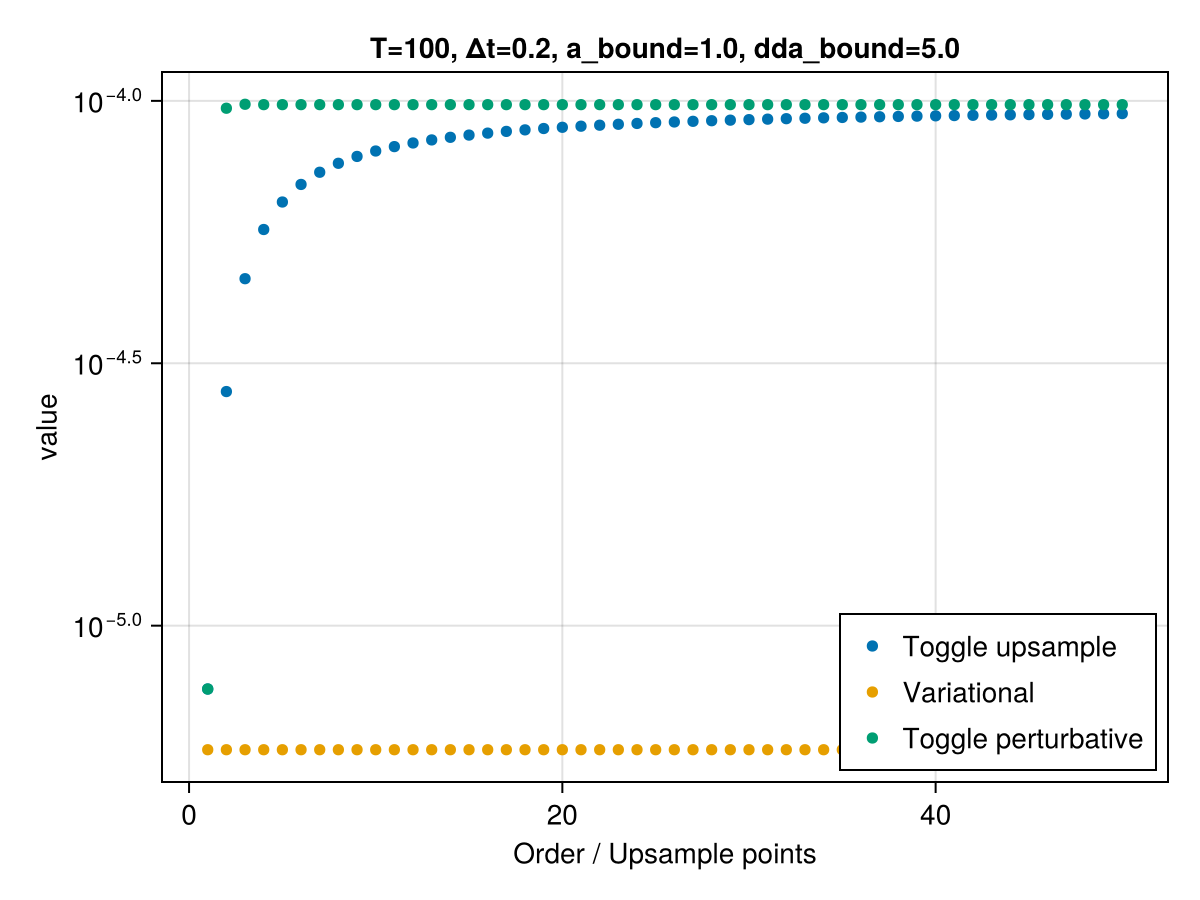

In [765]:
using CairoMakie

T = var_prob.trajectory.T
Δt = var_prob.trajectory.Δt[1]

fig = Figure()
ax = Axis(fig[1, 1], title="T=$T, Δt=$Δt, a_bound=$a_bound, dda_bound=$dda_bound",xlabel="Order / Upsample points", ylabel="value", yscale=log10)

CairoMakie.scatter!(ax, j_vals, t_vec; label="Toggle upsample", markersize=8)
CairoMakie.scatter!(ax, j_vals, v_vec; label="Variational", markersize=8)
CairoMakie.scatter!(ax, j_vals, t_vec_p; label="Toggle perturbative", markersize=8)

axislegend(ax, position=:rb)

fig

In [499]:
t_vec[end] / v_vec[end]

2.7673635159750383

In [500]:
t_vec_p[end] / v_vec[end]

2.9869358131391857

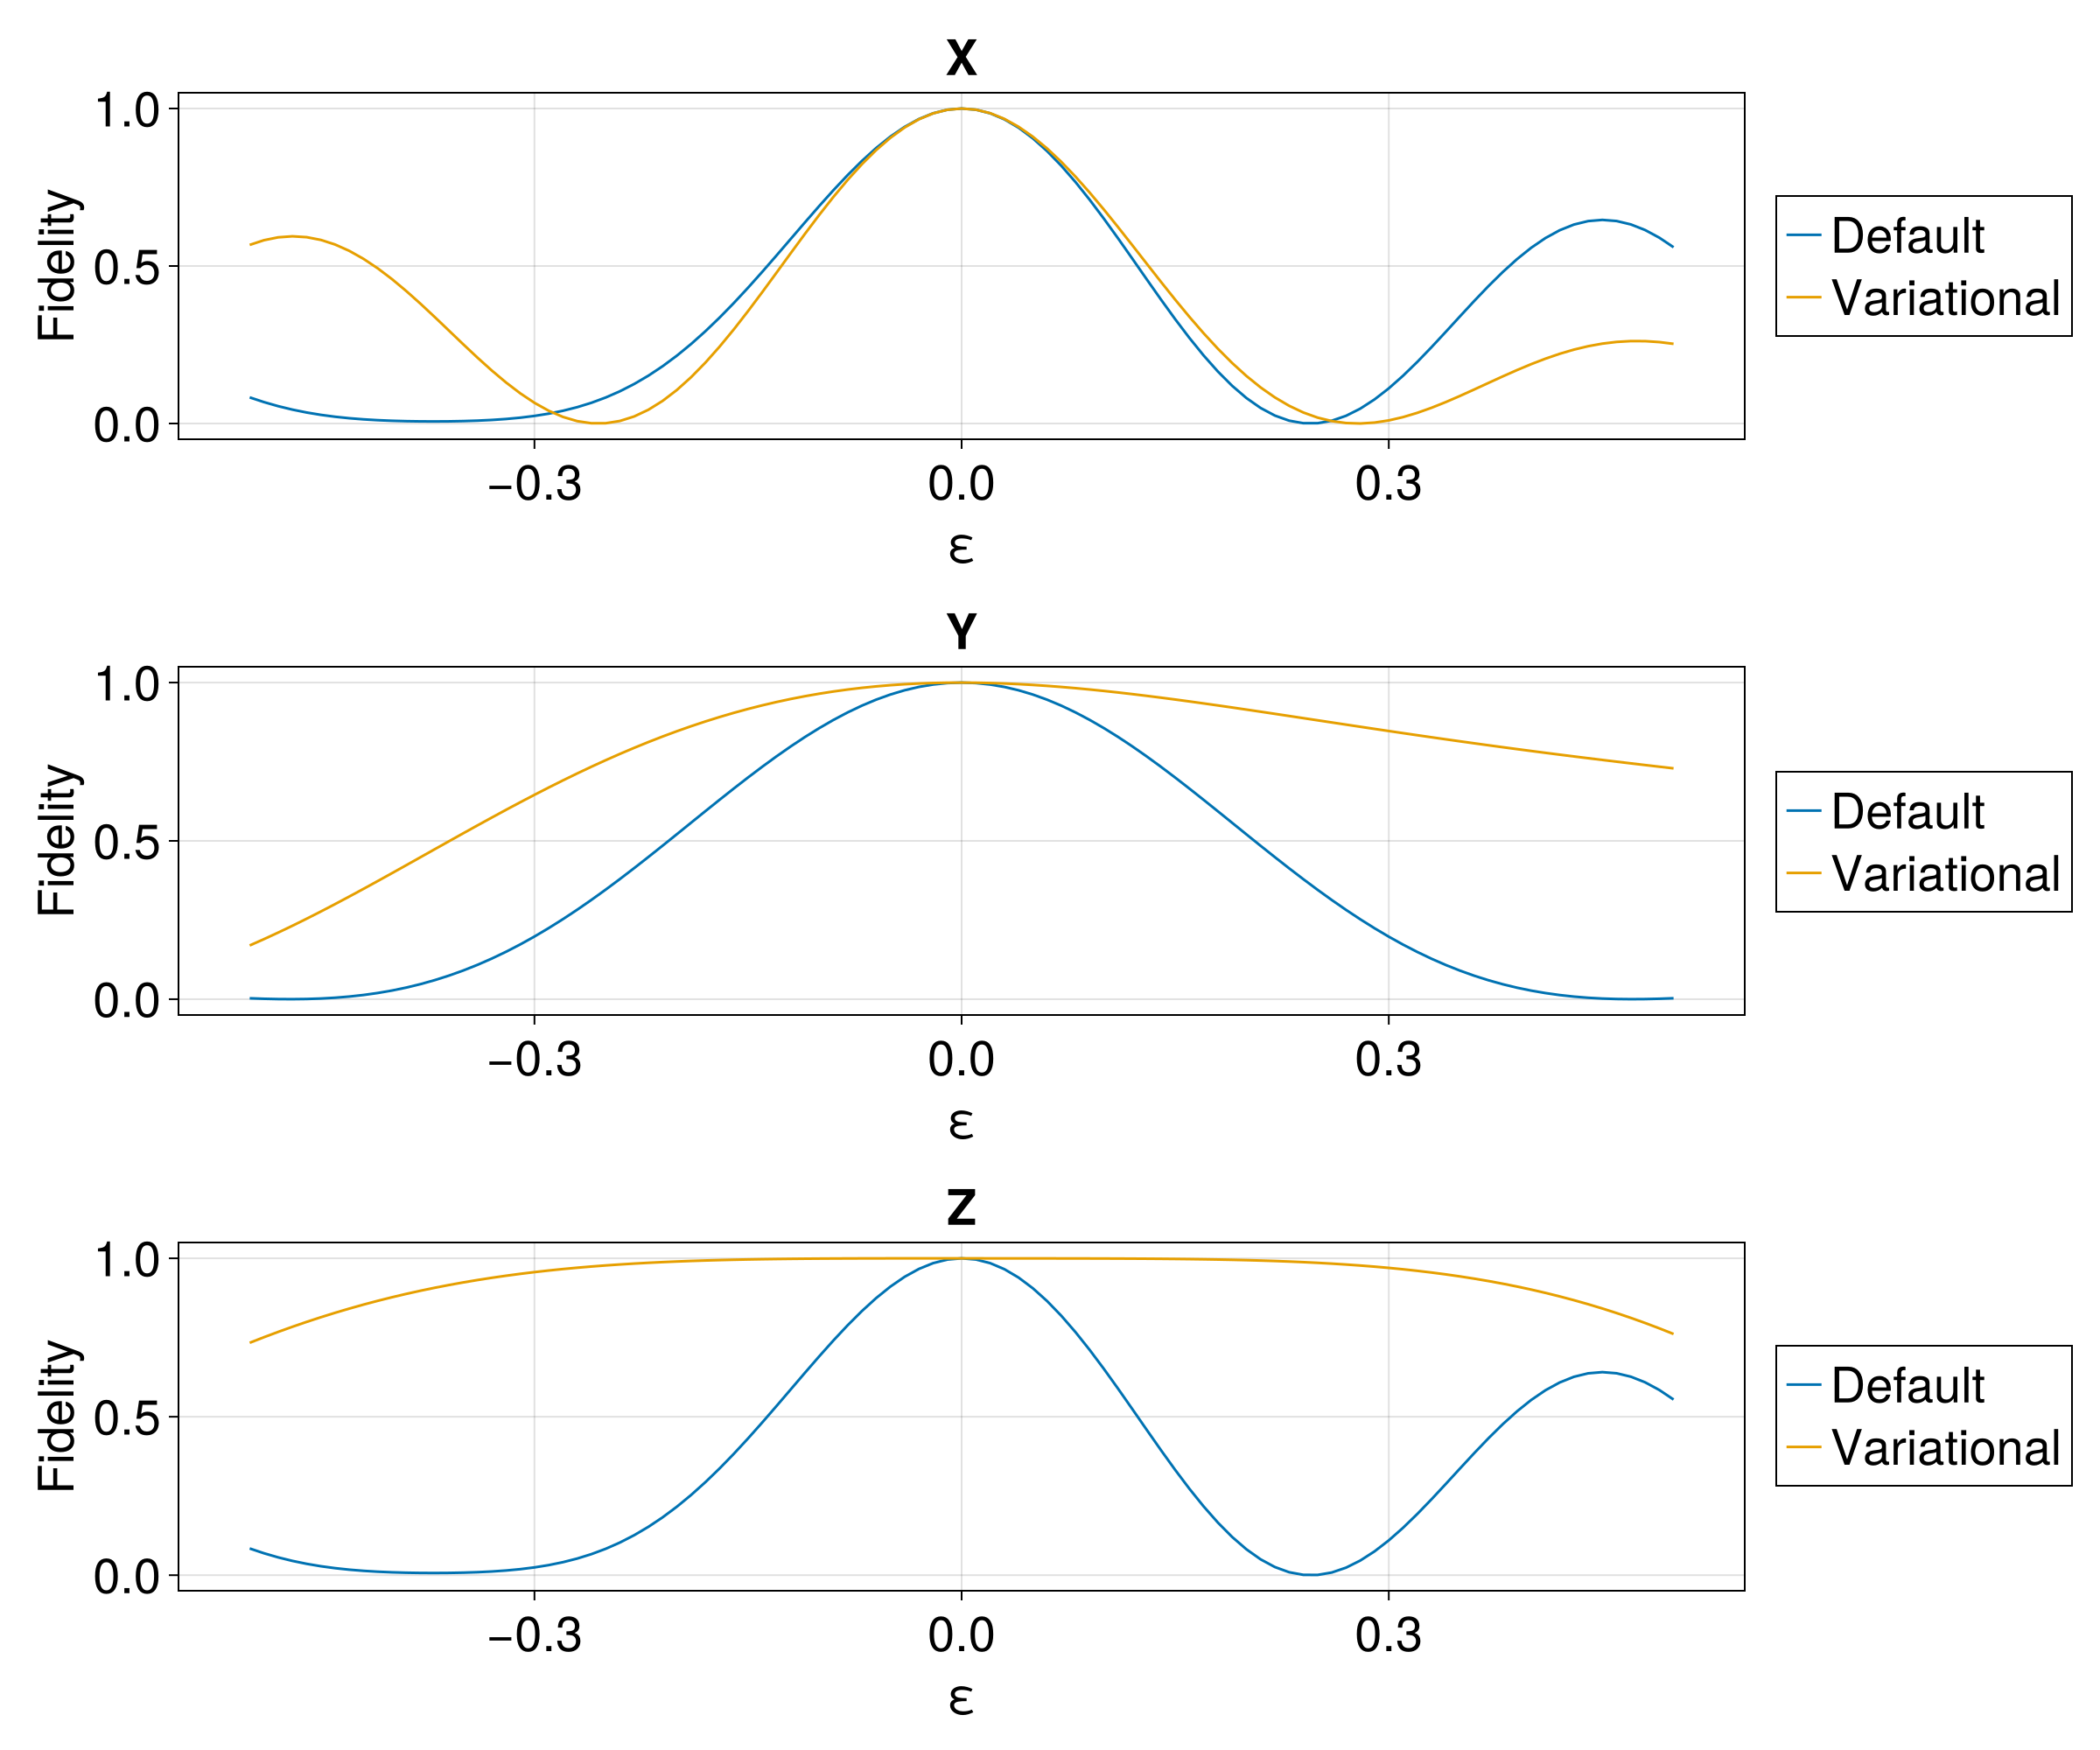

CairoMakie.Screen{IMAGE}


In [434]:
f = Figure(fontsize = 28, size = (1200, 1000))
axX = Axis(f[1, 1], title = "X", xlabel = "ε", ylabel = "Fidelity")#, yscale = log10)
axY = Axis(f[2, 1], title = "Y", xlabel = "ε", ylabel = "Fidelity")#, yscale = log10)
axZ = Axis(f[3, 1], title = "Z", xlabel = "ε", ylabel = "Fidelity")#, yscale = log10)

colors = Makie.wong_colors()
εs = -0.5:0.01:0.5

basis = [PAULIS.X, PAULIS.Y, PAULIS.Z]

axes_paulis = [
    (axX, PAULIS.X),
    (axY, PAULIS.Y),
    (axZ, PAULIS.Z),
]

problems = [
    (def,        "Default"),
    (var_prob, "Variational"),
    #(add_prob, "Toggling"),
    #(f_uni_prob,   "Universal"),
    # (f_uni_prob, "fast universal"),
    # (rf_uni_prob,"really fast universal"),
]

# Helper to compute the curve once per (problem, Pauli)
fidelity_curve(prob, pauli) = [unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * pauli, basis)) for ε in εs]

# Plot everything with two compact loops
for (ax, pauli) in axes_paulis
    for (i, (prob, label)) in enumerate(problems)
        ys = norm.(fidelity_curve(prob, pauli))
        lines!(ax, εs, ys; label = label, color = colors[i], linestyle = :solid)
    end
end

Legend(f[1, 2], axX, position = :lb)
Legend(f[2, 2], axY, position = :lb)
Legend(f[3, 2], axZ, position = :lb)

display(f)


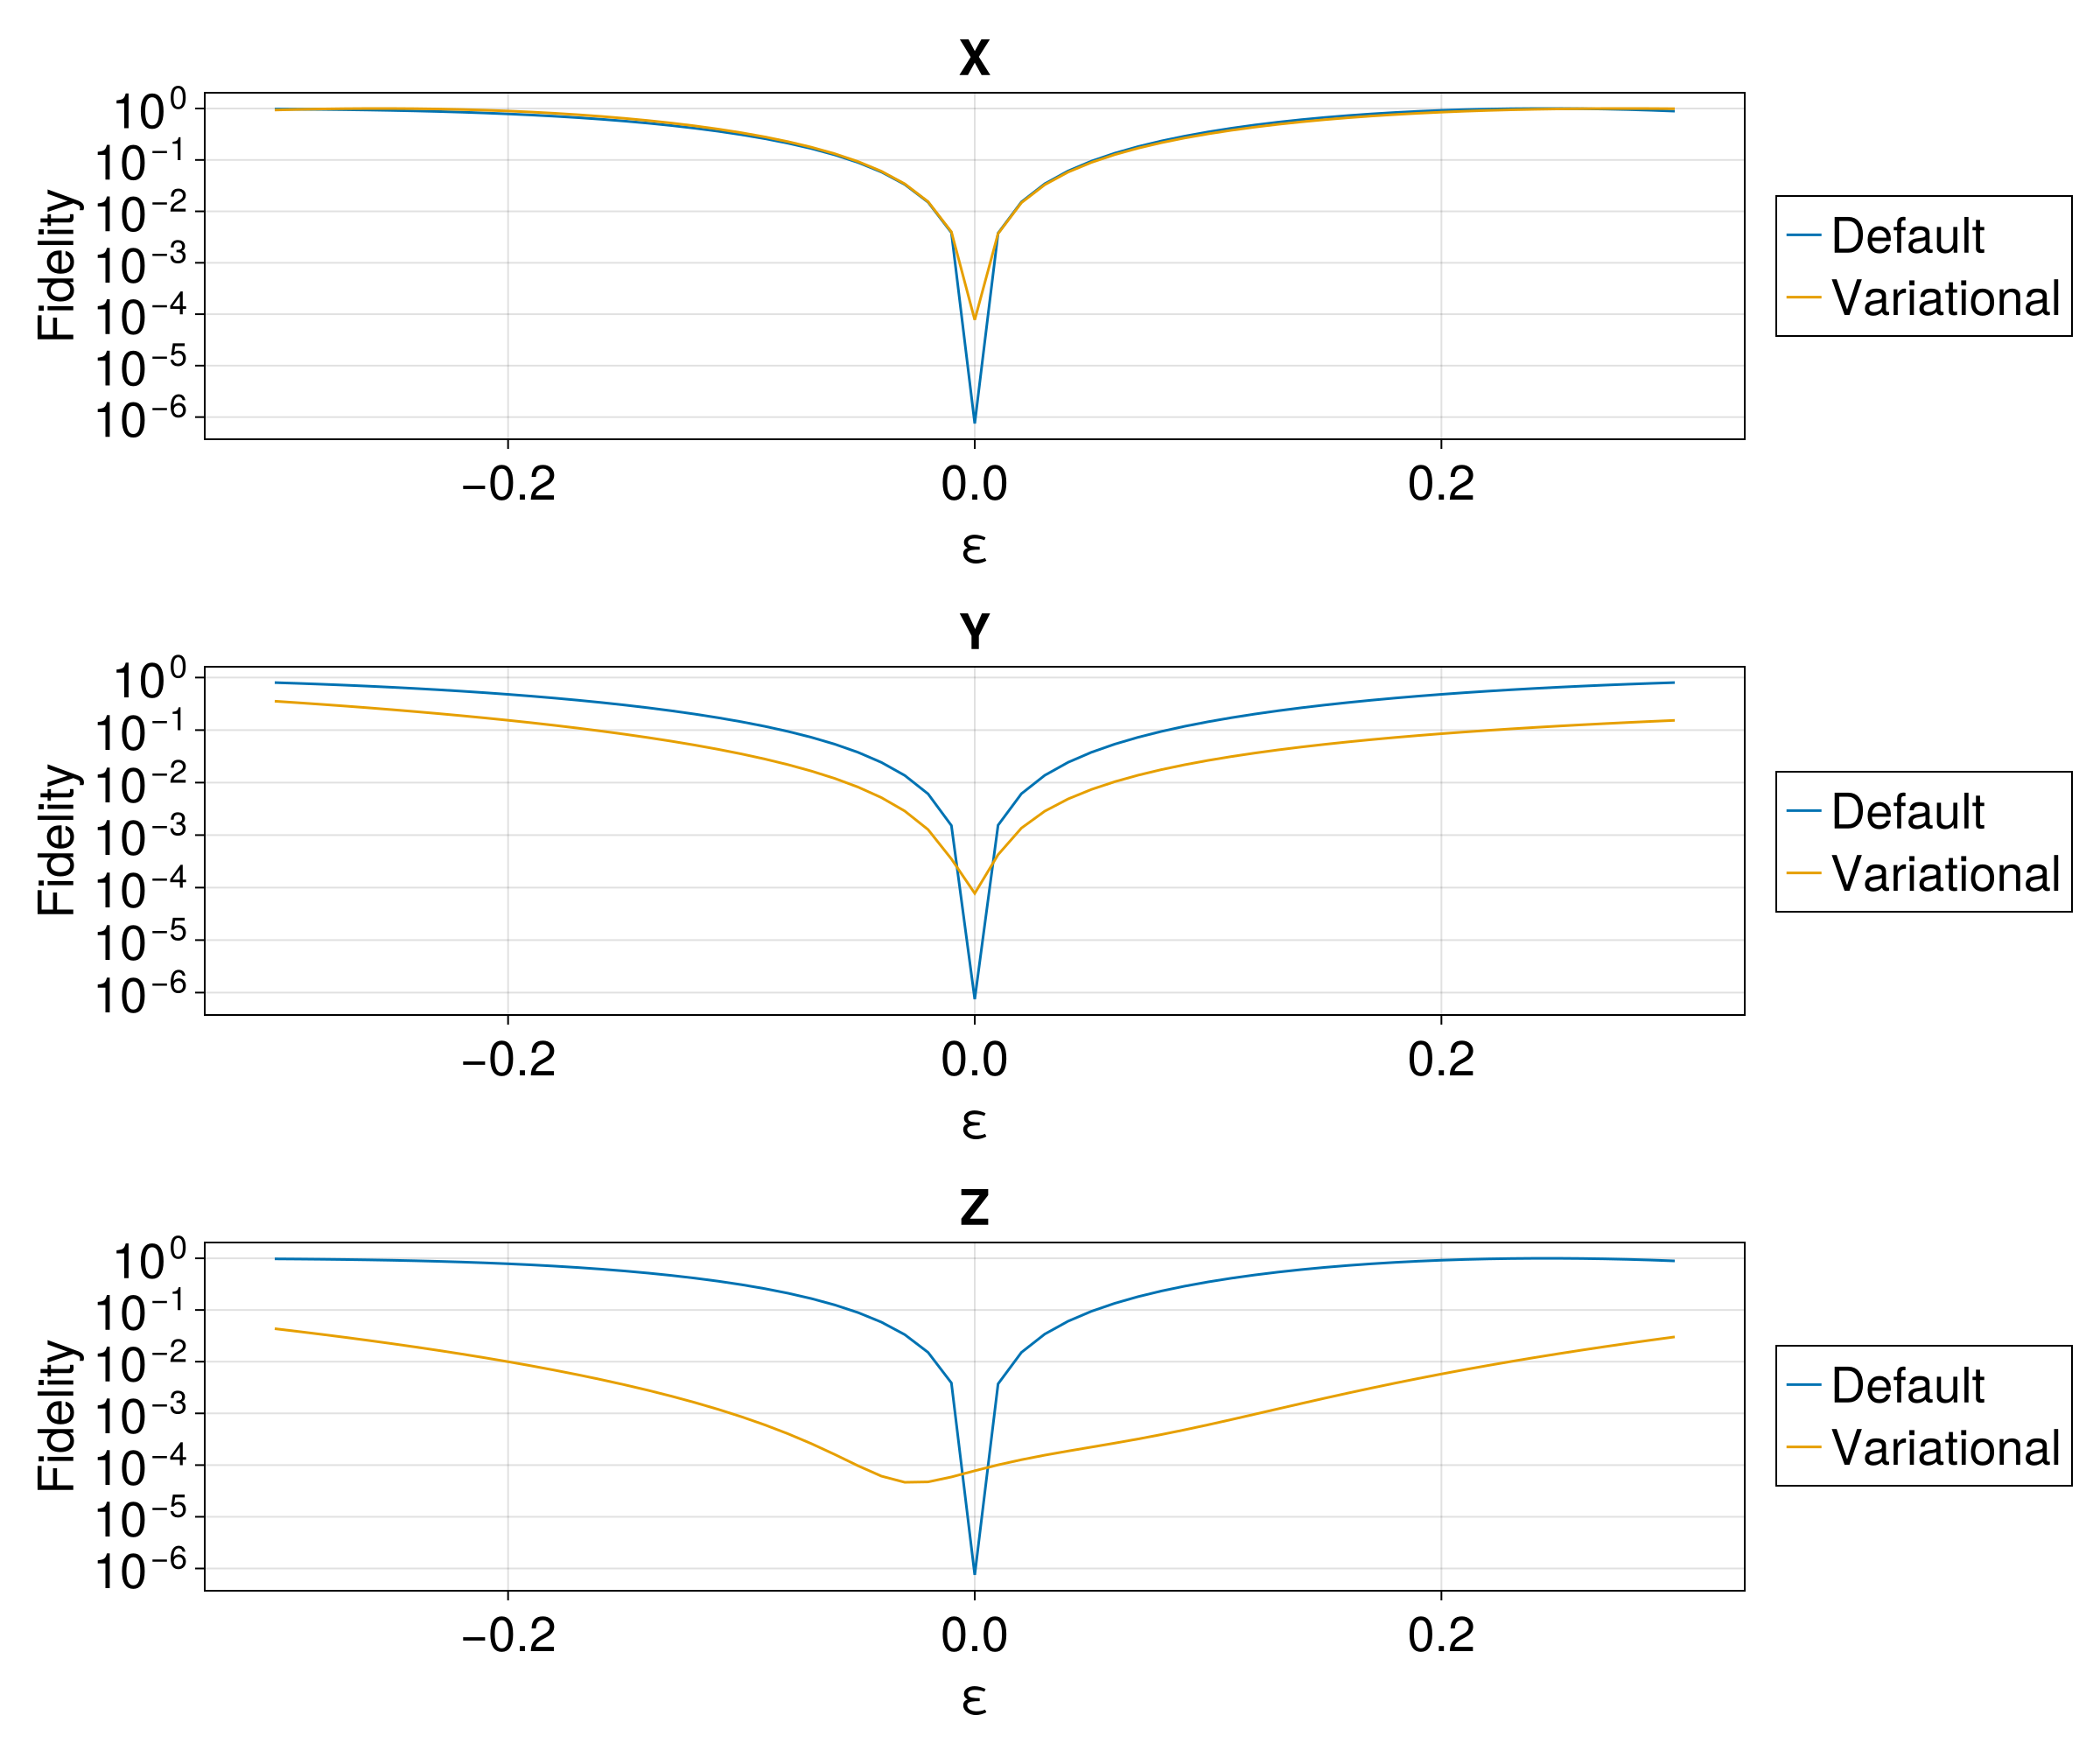

CairoMakie.Screen{IMAGE}


In [435]:
f = Figure(fontsize = 28, size = (1200, 1000))
axX = Axis(f[1, 1], title = "X", xlabel = "ε", ylabel = "Fidelity", yscale = log10)
axY = Axis(f[2, 1], title = "Y", xlabel = "ε", ylabel = "Fidelity", yscale = log10)
axZ = Axis(f[3, 1], title = "Z", xlabel = "ε", ylabel = "Fidelity", yscale = log10)

colors = Makie.wong_colors()
εs = -0.3:0.01:0.3

basis = [PAULIS.X, PAULIS.Y, PAULIS.Z]

axes_paulis = [
    (axX, PAULIS.X),
    (axY, PAULIS.Y),
    (axZ, PAULIS.Z),
]

problems = [
    (def,        "Default"),
    (var_prob, "Variational"),
    #(add_prob, "Toggling"),
    #(f_uni_prob,   "Universal"),
    # (f_uni_prob, "fast universal"),
    # (rf_uni_prob,"really fast universal"),
]

# Helper to compute the curve once per (problem, Pauli)
fidelity_curve(prob, pauli) = [unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * pauli, basis)) for ε in εs]

# Plot everything with two compact loops
for (ax, pauli) in axes_paulis
    for (i, (prob, label)) in enumerate(problems)
        ys = norm.(fidelity_curve(prob, pauli) .- 1)
        lines!(ax, εs, ys; label = label, color = colors[i], linestyle = :solid)
    end
end

Legend(f[1, 2], axX, position = :lb)
Legend(f[2, 2], axY, position = :lb)
Legend(f[3, 2], axZ, position = :lb)

display(f)
